In [1]:
import numpy as np
import pandas as pd
import random
import copy
import math
from collections import OrderedDict, Counter
#from multiprocessing import Pool
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

In [2]:
_Data_PATH_XX_ = './simulation_results/'
_Figure_PATH_XX_ = './figures/'

In [3]:
#时间步足够小 delta_t = 0.02
N = 2000        #节点数量

mu = 1          #恢复速率
beta = 0.6      #传播速率与接触人数的乘积
alpha = 0.5     #防护效果
w = 1         #行为更新速率 （如果结果不稳定，可能是由于更新过快的原因）
c0 = 1          #采取防护措施的花费
cI = 6          #被感染后的代价
ita = 0.001          #社会一致性的影响强度
k = 10           #每时间步平均接触人数或者网络度
gamma = 1       #由于媒体宣传，夸大感染能力或者对感染能力的误判

T = 2000         #运行时间
repeat_num = 30  #运行次数

#Init_condition_list = [0.01, 0.2]
n_inf = 0.01
n_take = 0.05    #初始采取防护措施的比例

beta_list = [0.02 * i for i in range(51)]
network_index = 0
network_list = ['regular','random','powerlaw']

In [4]:
filename1 = network_list[network_index] + 'inf_N'+str(N)+'k' + str(k) + '_mu'+ str(mu) + '_alpha' + str(alpha) + '_w' + str(w) + '_cI' +str(cI) +'_ita'+str(ita)+'gamma'+str(gamma)+'n_inf'+str(n_inf)+'n_take'+str(n_take)
filename2 = network_list[network_index] + 'take_N'+str(N)+'k' + str(k) + '_mu'+ str(mu) + '_alpha' + str(alpha) + '_w' + str(w) + '_cI' +str(cI) +'_ita'+str(ita)+'gamma'+str(gamma)+'n_inf'+str(n_inf)+'n_take'+str(n_take)

In [5]:
#导入仿真数据
inf_ave_list = []
take_ave_list = []
rho_I_dict = np.load(_Data_PATH_XX_ + filename1 + '.npy',allow_pickle=True).item()
rho_take_dict = np.load(_Data_PATH_XX_ + filename2 + '.npy',allow_pickle=True).item()

for key, value in rho_I_dict.items():
    inf_ave_list.append(np.mean(value))

for key, value in rho_take_dict.items():
    take_ave_list.append(np.mean(value))

print([rho_I_dict[0.56]])
print([rho_take_dict[0.56]])

[[0.8197491943157079, 0.8151743944213506, 0.8138756038280385, 0.8161573595522733, 0.8137788875416873, 0.8178724347799258, 0.8142955729955755, 0.8213725185913281, 0.8167644615525227, 0.8171021932370062, 0.8148577722310717, 0.816585633005749, 0.8133554974136951, 0.8180444447872808, 0.8172123875033948, 0.8173325012327435, 0.8169830002436989, 0.8187255633327211, 0.8199521637282448, 0.814372682436736, 0.8179152067381287, 0.8155879418256459, 0.8167909719460299, 0.8151999509998987, 0.8185997481260971, 0.8160328384652975, 0.8178806960402917, 0.8210797135150213, 0.8182899351245325, 0.8170181356602283]]
[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]


[]

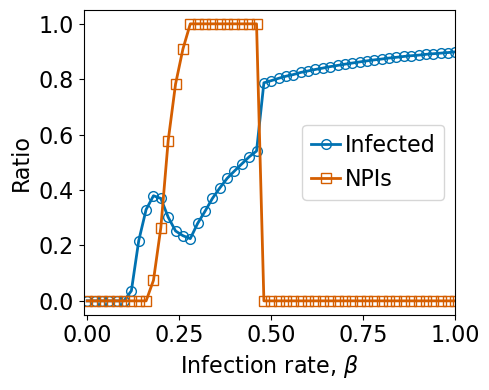

In [6]:
color_map=['#0072B2', '#D55E00', '#009E73', '#E69F00']
marker_shape = ['-o','-s','-^','d']
plt.figure(figsize=(5,4))

plt.plot(beta_list, inf_ave_list,marker_shape[0],markersize = 7, markerfacecolor='none',color=color_map[0],linewidth=2, label="Infected")
plt.plot(beta_list, take_ave_list,marker_shape[1],markersize = 7, markerfacecolor='none',color=color_map[1],linewidth=2, label="NPIs")

font1 = {'weight': 'normal','size':16}
font2 = {'weight': 'normal','size':16}
plt.legend(fontsize=16, handlelength=1.3,handletextpad=0.2)
#plt.legend(fontsize=16)
#plt.ylim((-0.01,1))
plt.xlim((-0.01,1))
#plt.xticks([0.5,1,1.5,2,2.5,3,3.5],['0.5','1','1.5','2','2.5','3','3.5'])
plt.subplots_adjust(left=0.19,bottom=0.17,right=0.94)
plt.tick_params(labelsize=16)
plt.xlabel('Infection rate, $\\beta$',font1)
#plt.xlabel('cI',font1)
#plt.xlabel('alpha',font1)
#plt.xlabel('$\\gamma$',font1)
#plt.xlabel('ita',font1)
plt.ylabel('Ratio',font1)
plt.tight_layout()
plt.savefig(_Figure_PATH_XX_ + network_list[network_index]+ 'figure' + '.png', dpi = 400)
plt.plot()